Tests w/ ucbvi

In [9]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
                        message="Overriding environment .* already in registry")

In [10]:
import numpy as np, matplotlib.pyplot as plt
from causal_gym.envs.cartpole_wind import CartPoleWindPCH
import sys
sys.path.insert(0, '../..')  # Go up two levels to reach the causal2 directory
from cartpole.ucbvi import UCBVI


== CartPole‑Wind training ==

UCB-VI  Ep 2000/2000 | Return: 200.0 | ε=0.10 | ETA: 0.0s
No-plan Ep 2000/2000 | Return:  9.0 | ε=0.10 | ETA: 0.0s
Random  Ep 2000/2000 | Return: 66.0 | ε=0.10 | ETA: 0.0s


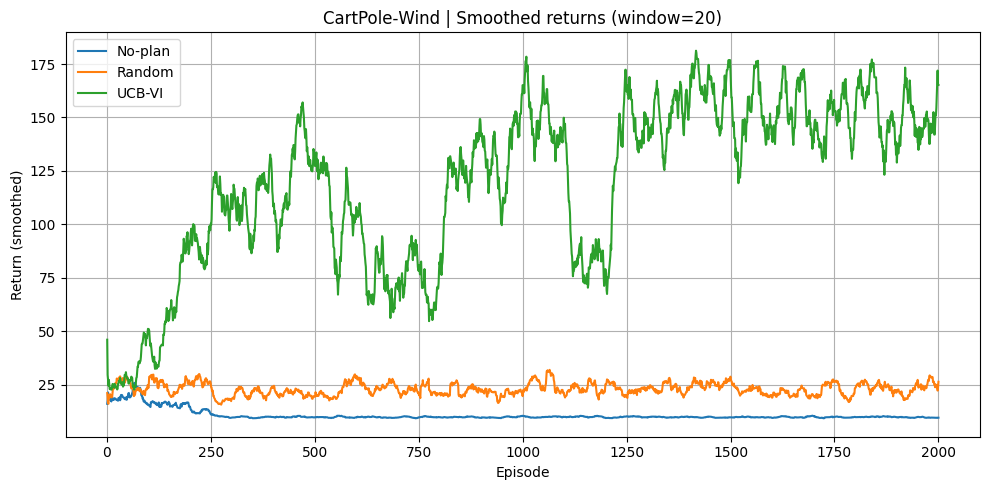

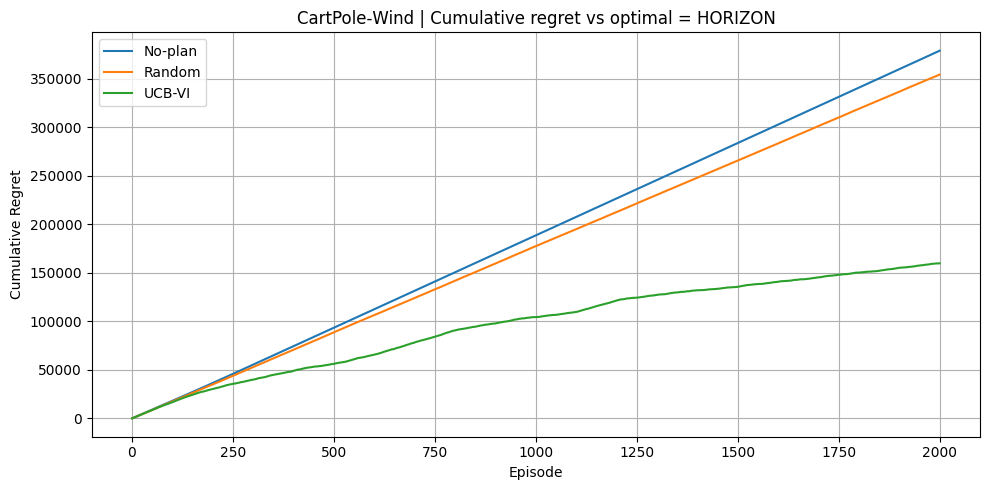

In [11]:
# %%
"""wind_cartpole_experiments.py – v4 (adds cumulative regret)
=================================================================
Train three policies on the wind‑driven Cart‑Pole and show **both**
smoothed returns *and* cumulative regret curves, printed progress
lines, no CSV writes unless `SAVE_CSV=True`.

Regret definition
-----------------
Regret per episode = *optimal_return* − episode_return.  For classic
Cart‑Pole the maximum reward per step is +1 and episodes are capped at
``HORIZON`` steps, so the per‑episode optimum is simply ``HORIZON``.
Cumulative regret highlights how quickly each algorithm closes that
gap.

Policies
~~~~~~~~
1. **UCB‑VI**   – optimistic planning, re‑plan every ``PLAN_K`` eps.  
2. **No‑plan**  – model updates but never calls ``plan()``.  
3. **Random**   – iid uniform actions (RCT baseline).
"""

# %% Imports & configuration -------------------------------------------
import time, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartpole_wind_pch import CartPoleWindPCH
from cartpole.ucbvi import UCBVI

# ── hyper‑parameters ─────────────────────────────────────────────────––
NUM_EPISODES   = 2000
WIND_STD       = 0.02
BINS_PER_DIM   = 6
HORIZON        = 200        # also used as per‑episode optimum
DELTA          = 0.1
EPS_DECAY_END  = 300        # epsilon decays linearly → 0.1 at this ep
PLAN_K         = 5          # re‑plan frequency for UCB‑VI variant
SAVE_CSV       = True       # set True to dump logs under OUT_DIR
OUT_DIR        = Path("logs")

# ‑‑ pre‑compute constants ‑‑
OPT_RETURN = HORIZON        # ideal reward if pole never falls

# %% Helper ----------------------------------------------------------------

def train_variant(label: str,
                  plan_every_k: int | None = None,
                  random_policy: bool = False) -> pd.DataFrame:
    """Run one algorithm variant and return per‑episode stats."""
    env   = CartPoleWindPCH(wind_std=WIND_STD)
    agent = UCBVI(BINS_PER_DIM, env.env.action_space.n, HORIZON, DELTA)

    ep_returns, ep_regrets = [], []
    start_time  = time.time()
    agent.plan()                     # optimistic warm‑start

    for ep in range(NUM_EPISODES):
        obs, _   = env.env.reset()
        tot_ret  = 0.0
        epsilon  = max(0.1, 1.0 - ep / EPS_DECAY_END)

        for t in range(HORIZON):
            s = agent.discretize(obs)
            if random_policy:
                act = env.env.np_random.integers(env.env.action_space.n)
            elif np.random.rand() < epsilon:
                act = np.random.randint(agent.A)
            else:
                act = agent.act(s)

            obs2, r, term, trunc, _ = env.do(act)
            s2 = agent.discretize(obs2)
            agent.update(s, act, r, s2)
            obs = obs2
            tot_ret += r
            if term or trunc:
                break

        # periodic planning
        if plan_every_k is not None and (ep + 1) % plan_every_k == 0:
            agent.plan()

        # live progress -------------------------------------------------
        elapsed = time.time() - start_time
        avg_ep  = elapsed / (ep + 1)
        eta     = avg_ep * (NUM_EPISODES - ep - 1)
        print(f"{label:<7} Ep {ep+1:3d}/{NUM_EPISODES} | Return: {tot_ret:4.1f} | "
              f"ε={epsilon:.2f} | ETA:{eta:4.1f}s", end="\r", flush=True)

        ep_returns.append(tot_ret)
        ep_regrets.append(OPT_RETURN - tot_ret)

    print()              # newline after carriage‑return spam
    env.env.close()

    df = pd.DataFrame({
        "Episode": np.arange(1, NUM_EPISODES + 1),
        "Return":  ep_returns,
        "Regret":  ep_regrets,
        "Variant": label
    })
    df["CumRegret"] = df["Regret"].cumsum()
    return df

# %% Run all variants ---------------------------------------------------
print("\n== CartPole‑Wind training ==\n")

results = pd.concat([
    train_variant("UCB-VI",  plan_every_k=PLAN_K),
    train_variant("No-plan", plan_every_k=None),
    train_variant("Random",  random_policy=True)
], ignore_index=True)

if SAVE_CSV:
    OUT_DIR.mkdir(exist_ok=True)
    for v, grp in results.groupby("Variant"):
        grp.to_csv(OUT_DIR / f"{v.lower()}_log.csv", index=False)

# %% Plot returns --------------------------------------------------------
window = 20
plt.figure(figsize=(10, 5))
for var, grp in results.groupby("Variant"):
    plt.plot(grp["Episode"],
             grp["Return"].rolling(window, min_periods=1).mean(),
             label=var)
plt.xlabel("Episode"); plt.ylabel("Return (smoothed)")
plt.title("CartPole‑Wind | Smoothed returns (window=20)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# %% Plot cumulative regret ---------------------------------------------
plt.figure(figsize=(10, 5))
for var, grp in results.groupby("Variant"):
    plt.plot(grp["Episode"], grp["CumRegret"], label=var)
plt.xlabel("Episode"); plt.ylabel("Cumulative Regret")
plt.title("CartPole‑Wind | Cumulative regret vs optimal = HORIZON")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
